# Wine Classification with Support Vector Machine (SVC)

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.datasets import load_wine

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

This notebook demonstrates a simple classification task using the Wine dataset and a Support Vector Machine (SVC) classifier from `scikit-learn`.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [3]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay

## 1. Data Loading

We load the Wine dataset, which is a classic dataset for classification. It contains 13 attributes and 3 classes of wine.

In [4]:
df=load_wine()
df

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## 2. Data Preparation

We separate the features (`x`) from the target variable (`y`) and then split the data into training and testing sets. This allows us to train our model on one part of the data and evaluate its performance on unseen data.

In [5]:
x=df.data
y=df.target

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## 3. Model Training

We initialize a Support Vector Classifier (SVC) model and train it using the training data (`x_train`, `y_train`).

In [7]:
classifier=SVC()

In [8]:
classifier.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## 4. Prediction

After training, we use the trained classifier to make predictions on the test set (`x_test`).

In [9]:
y_pred=classifier.predict(x_test)

## 5. Model Evaluation

Finally, we evaluate the performance of our SVC model using a classification report and a confusion matrix.

The classification report provides precision, recall, and f1-score for each class, while the confusion matrix visually summarizes the true positive, true negative, false positive, and false negative predictions.

In [10]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.73      0.79      0.76        14
           2       0.57      0.50      0.53         8

    accuracy                           0.81        36
   macro avg       0.77      0.76      0.76        36
weighted avg       0.80      0.81      0.80        36



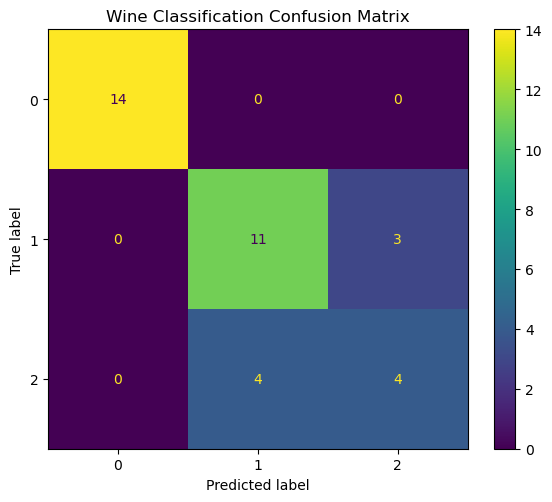

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title("Wine Classification Confusion Matrix")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

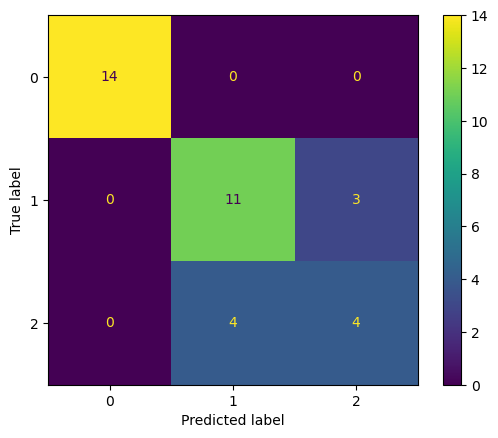

In [12]:
ConfusionMatrixDisplay.from_estimator(classifier,x_test,y_test)

## Visualizing the Hyperplane with PCA

Since the Wine dataset has 13 features, direct visualization of the hyperplane is not possible. We'll use Principal Component Analysis (PCA) to reduce the data to two dimensions, which will allow us to plot the decision boundary of the SVC.

We will retrain the SVC on this 2D projected data.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize the data before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Split the PCA-transformed data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Train a new SVC classifier on the PCA-transformed data
svc_pca = SVC(kernel='linear') # Using a linear kernel for clear hyperplane visualization
svc_pca.fit(X_train_pca, y_train_pca)

print("SVC model trained on 2D PCA-transformed data.")

SVC model trained on 2D PCA-transformed data.


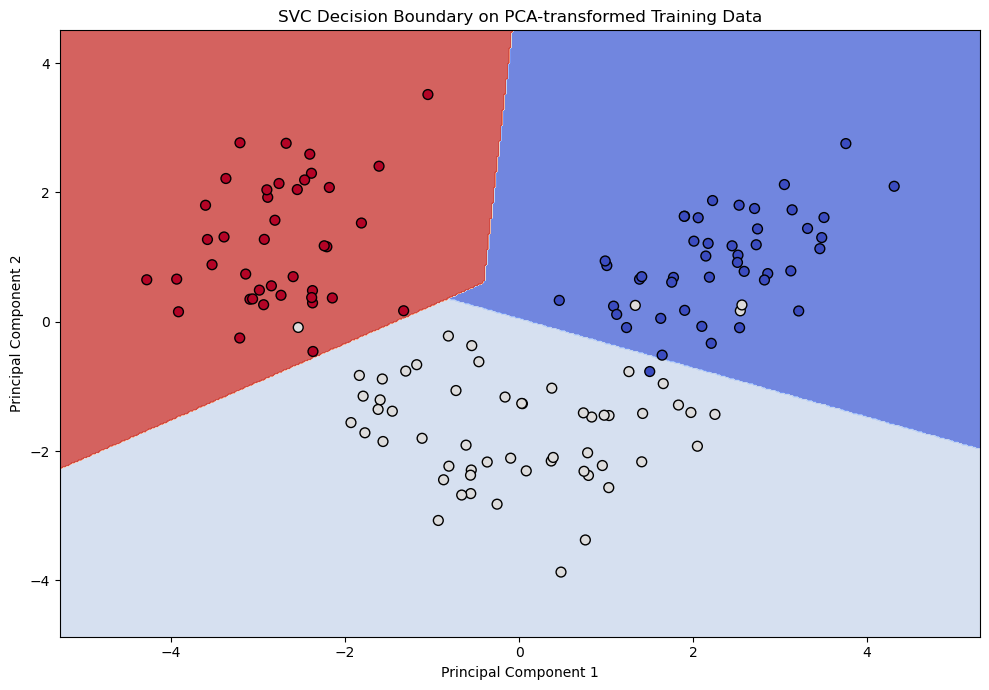

In [17]:
def plot_decision_boundary(model, X, y, title="Decision Boundary", output_path=None):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    fig, ax = plt.subplots(figsize=(10, 7))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors="k")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_decision_boundary(
    svc_pca,
    X_train_pca,
    y_train_pca,
    title="SVC Decision Boundary on PCA-transformed Training Data",
    output_path=OUTPUT_DIR / "pca_decision_boundary.png",
)

## Conclusion

In this notebook, we performed a classification task on the Wine dataset using a Support Vector Classifier (SVC).

**Key Takeaways:**
- We successfully loaded and prepared the Wine dataset.
- An SVC model was trained and evaluated, showing reasonable performance for classifying wine types.
- We used Principal Component Analysis (PCA) to reduce the dimensionality of the data to 2D, allowing for a visual representation of the SVC's decision boundary.
- The decision boundary plot helps in understanding how the model separates different classes in a simplified feature space.

**Further Enhancements:**
- Hyperparameter tuning for the SVC model to optimize performance.
- Exploring other dimensionality reduction techniques.
- Investigating the impact of different preprocessing steps on model accuracy.

## Exported artifacts

The notebook saves the trained model and evaluation plots in the `outputs/` directory. The model bundle includes the original SVC, the scaler and PCA transformer used for visualization, and dataset metadata.

In [19]:
model_bundle = {
    "classifier": classifier,
    "scaler": scaler,
    "pca": pca,
    "pca_classifier": svc_pca,
    "feature_names": df.feature_names,
    "target_names": df.target_names,
}

model_path = OUTPUT_DIR / "wine_svc_model.pkl"
joblib.dump(model_bundle, model_path)
loaded_model_bundle = joblib.load(model_path)
print(f"Saved and verified model at {model_path}")
print(f"Model bundle keys: {sorted(loaded_model_bundle)}")
print(f"Saved plots to {OUTPUT_DIR.resolve()}")

Saved and verified model at outputs\wine_svc_model.pkl
Model bundle keys: ['classifier', 'feature_names', 'pca', 'pca_classifier', 'scaler', 'target_names']
Saved plots to C:\Users\moham\OneDrive\Attachments\Desktop\MACHINE LEARNING PROJECTS\MACHINE_LEARNING_PROJECT\Wine_Classification\outputs
